# DrainEye - Классификация дефектов дренажа

Обучение базовой модели на датасете [draineye-defects](https://huggingface.co/datasets/draineye/draineye-defects) (corrosion / crack / no_damage).

## Установка зависимостей


In [ ]:
!pip install tensorflow==2.19.0 scikit.learn==1.6.1 numpy==2.0.2 matplotlib==3.10.0 datasets==4.0.0

In [ ]:
import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["HF_HOME"] = "/content/drive/MyDrive/draineye/cache"

In [67]:
from datasets import load_dataset

from google.colab import userdata, drive

import random
import numpy as np

from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import Resizing, Lambda, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import Input, Model

from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

%matplotlib inline

## Конфигурация


### Гиперпараметры

In [32]:
SEED=42
BATCH_SIZE=16
EPOCH=12

IMG_SHAPE=(224, 224, 3)

DATASET_NAME="draineye/draineye-defects"
DATASET_VERSION="v1.0"

DRIVE_PATH = "/content/drive/MyDrive/draineye/"

### Монитрование

In [ ]:
drive.mount("/content/drive/")

## Установка датасета


In [6]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

dataset = load_dataset(
    DATASET_NAME,
    revision=DATASET_VERSION
  )

dataset

Resolving data files:   0%|          | 0/1050 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1050
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 225
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 225
    })
})

## Подготовка датасета

### Воспроизводимость


In [7]:
def set_global_seed(seed: int) -> None:
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)

set_global_seed(SEED)

### Преобразование датасета

In [9]:
def make_tf_dataset(hf_dataset, split: str, shuffle: bool) -> tf.data.Dataset:
  return hf_dataset[split].to_tf_dataset(
      columns="image",
      label_cols="label",
      shuffle=shuffle
  ).map(lambda image, label: (tf.image.resize(image, IMG_SHAPE[:2]), label)) \
   .batch(batch_size=BATCH_SIZE) \
   .cache().prefetch(tf.data.AUTOTUNE)

train = make_tf_dataset(dataset, "train", True)
validation = make_tf_dataset(dataset, "validation", False)
test = make_tf_dataset(dataset, "test", False)

## Анализ датасета

In [10]:
labels = dataset["train"].features["label"].names
labels

['corrosion', 'crack', 'no_damage']

### Проверка баланса классов

In [11]:
print("Баланс классов: ", end='\n\t')
for dts in ["train", "validation", "test"]:
  cls, counts = np.unique(dataset[dts]["label"], return_counts=True)
  print(f"{dts}: {dict(zip(labels, counts.tolist()))}", end='\n\t')

Баланс классов: 
	train: {'corrosion': 350, 'crack': 350, 'no_damage': 350}
	validation: {'corrosion': 75, 'crack': 75, 'no_damage': 75}
	test: {'corrosion': 75, 'crack': 75, 'no_damage': 75}
	

### Пример датасета

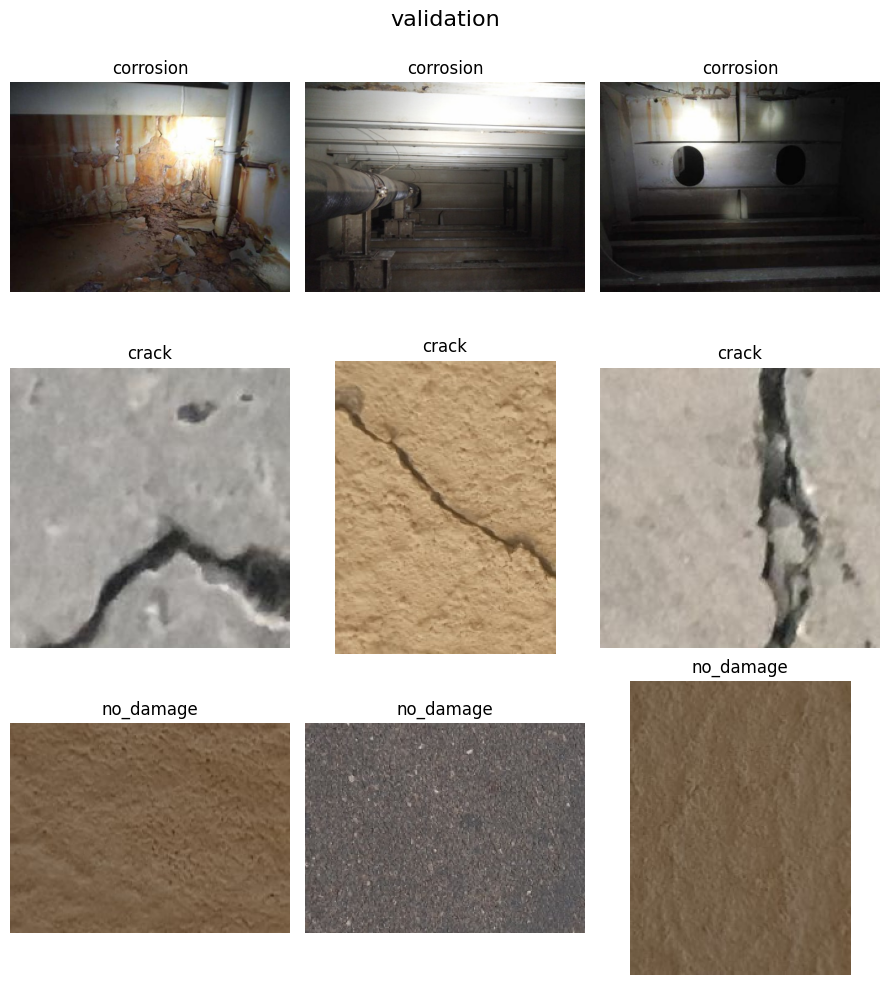

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for (lbl_idx, label) in enumerate(labels):
  imgs = dataset["train"].filter(lambda x: x["label"] == lbl_idx) \
                         .shuffle() \
                         .select(range(3))["image"]

  for (img_idx, img) in enumerate(imgs):
    axes[lbl_idx][img_idx].imshow(img)
    axes[lbl_idx][img_idx].set_title(labels[lbl_idx])
    axes[lbl_idx][img_idx].axis("off")

plt.tight_layout()
plt.show()

### Гистограмма яркости пикселей

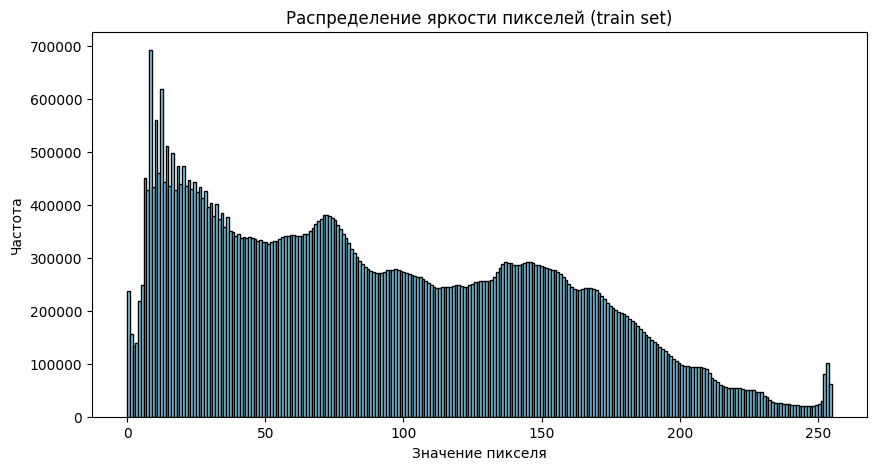

In [13]:
pixels = np.concatenate([np.array(img).flatten() for img in dataset["train"].shuffle().select(range(100))["image"]])

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(pixels, bins=256, color="skyblue", edgecolor="black")

ax.set_title("Распределение яркости пикселей (train set)")
ax.set_xlabel("Значение пикселя")
ax.set_ylabel("Частота")

plt.show()

## Случайный классификатор

In [14]:
from sklearn.dummy import DummyClassifier

y_train = np.array(dataset["train"]["label"])
X_train = np.zeros(len(y_train))

y_test = np.array(dataset["test"]["label"])
X_test = np.zeros(len(y_test))

dummy_cls = DummyClassifier(strategy="stratified")
dummy_cls = dummy_cls.fit(X_train, y_train)
score = dummy_cls.score(X_test, y_test)

print(f"Точность случайного классификатора: {score*100:.2f}%")

Точность случайного классификатора: 36.89%
